# Maryland GOP Governor Nominee Forecast

Exploratory notebook for the June 23, 2026 Maryland Republican gubernatorial primary forecast.

The notebook uses the production pipeline in `scripts/build_dataset.py`; it does not contain a separate model implementation. Prediction-market data is shown only as an external price check and is not used in the core forecast.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
AS_OF = "2026-05-20"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

ROOT

PosixPath('/Users/deepak/Desktop/Maryland Republican Governor Nominee')

## Rebuild Forecast Package

Run the same pipeline used by the command line build. This refreshes processed CSVs, model output, audit report, model card, and the raw snapshot manifest.

In [2]:
from scripts.build_dataset import main as build_dataset

result = build_dataset(AS_OF)
result.keys()

dict_keys(['candidate_scores', 'scenarios', 'release_status', 'wager_value_table'])

## Headline Output

In [3]:
model_output = json.loads((PROCESSED_DIR / "model_output.json").read_text())
model_output["headline_forecast"], model_output["release_status"]

({'candidate': 'Dan Cox', 'probability': 0.3383},
 {'release_status': 'withheld',
  'forecast_publishable': False,
  'betting_eligible': False,
  'reliability_score': 26,
  'reliability_class': 'low',
  'blocking_issues': 'no_credible_public_polling;finance_incomplete_for_full_field;stale_market_price;verify_contract_terms;edge_not_durable_across_scenarios',
  'reliability_penalties': 'polling_component_unavailable;finance_missing_for_some_active_candidates;plurality_field_high_uncertainty'})

In [4]:
scores = pd.read_csv(PROCESSED_DIR / "candidate_forecast.csv")
scores[[
    "rank",
    "candidate",
    "lieutenant_governor",
    "home_jurisdiction",
    "forecast_probability",
    "model_score",
    "historical_score",
    "finance_score",
    "event_score",
    "local_geography_score",
]]

,rank,candidate,lieutenant_governor,home_jurisdiction,forecast_probability,model_score,historical_score,finance_score,event_score,local_geography_score
0,1,Dan Cox,Rob Krop,Frederick County,0.338328,24.441083,9.359246,0.000000,7.011486,0.940120
1,2,Ed Hale,Tyrone Keys Jr.,Talbot County,0.194164,19.998595,0.000000,7.897447,-2.494257,0.797460
2,3,John A. Myrick,Brenda J. Thiam,Prince George's County,0.185193,19.620161,0.000000,6.053206,1.482771,0.834184
3,4,Shannon Wright,Reba A. Hawkins,Baltimore City,0.087762,13.646026,2.000000,0.000000,3.482771,0.785172
4,5,Carl A. Brunner Jr.,Kevin L. Rhodes Sr.,Carroll County,0.048421,8.888412,0.000000,0.000000,0.000000,0.939781
5,6,Douglas Larcomb,Martina D. Duncan,Carroll County,0.042731,7.888306,0.000000,0.000000,1.482771,0.939781
6,7,L. D. Burkindine,Jeremy M. Shifflett,Queen Anne's County,0.037394,6.821080,0.000000,0.000000,0.000000,0.822450
7,8,Nancy Jane Taylor,"Rachel Hannah ""Mohawk"" Swift",Washington County,0.034396,6.152467,0.000000,0.000000,0.000000,0.898357
8,9,Michael Oakes,Ronald W. Abend,Carroll County,0.031610,5.476768,0.000000,0.000000,0.000000,0.939781


Text(0, 0.5, '')

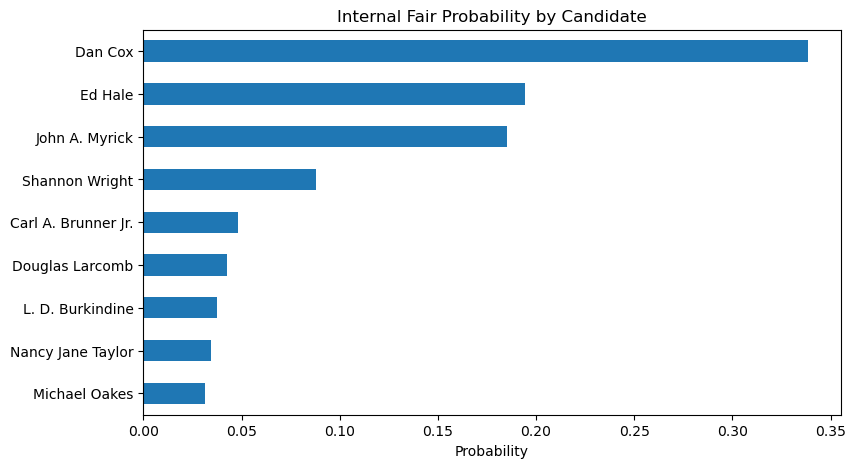

In [5]:
ax = scores.sort_values("forecast_probability").plot.barh(
    x="candidate",
    y="forecast_probability",
    legend=False,
    figsize=(9, 5),
    title="Internal Fair Probability by Candidate",
)
ax.set_xlabel("Probability")
ax.set_ylabel("")

## Scenario Stress Tests

These are not separate predictions. They show whether the top candidate survives plausible race-shape changes, such as a Cox repeat-base consolidation, Hale money/moderate-lane surge, or debate-attention surge for Myrick/Wright/Larcomb.

In [6]:
scenarios = pd.read_csv(PROCESSED_DIR / "model_scenarios.csv")
scenario_leaders = (
    scenarios.sort_values(["scenario", "scenario_probability"], ascending=[True, False])
    .groupby("scenario")
    .head(3)
    .reset_index(drop=True)
)
scenario_leaders

,scenario,candidate,scenario_probability,last_updated
0,baseline,Dan Cox,0.338328,2026-05-20
1,baseline,Ed Hale,0.194164,2026-05-20
2,baseline,John A. Myrick,0.185193,2026-05-20
3,cox_repeat_base_consolidation,Dan Cox,0.457415,2026-05-20
4,cox_repeat_base_consolidation,Ed Hale,0.159219,2026-05-20
5,cox_repeat_base_consolidation,John A. Myrick,0.151863,2026-05-20
6,fragmented_field_plurality,Dan Cox,0.312692,2026-05-20
7,fragmented_field_plurality,Ed Hale,0.189699,2026-05-20
8,fragmented_field_plurality,John A. Myrick,0.181792,2026-05-20
9,hale_money_moderate_surge,Ed Hale,0.307873,2026-05-20


In [7]:
scenario_matrix = scenarios.pivot(index="candidate", columns="scenario", values="scenario_probability")
scenario_matrix.loc[scores["candidate"]].round(3)

scenario,baseline,cox_repeat_base_consolidation,fragmented_field_plurality,hale_money_moderate_surge,high_turnout,late_trump_or_major_gop_endorsement,low_turnout,mail_ballot_admin_uncertainty,myrick_wright_larcomb_debate_surge
candidate,,,,,,,,,
Dan Cox,0.338,0.457,0.313,0.270,0.305,0.439,0.396,0.326,0.288
Ed Hale,0.194,0.159,0.190,0.308,0.225,0.144,0.177,0.192,0.165
John A. Myrick,0.185,0.152,0.182,0.167,0.215,0.165,0.169,0.184,0.244
Shannon Wright,0.088,0.072,0.093,0.079,0.079,0.078,0.080,0.090,0.116
Carl A. Brunner Jr.,0.048,0.040,0.054,0.044,0.044,0.043,0.044,0.051,0.041
Douglas Larcomb,0.043,0.035,0.049,0.039,0.039,0.038,0.039,0.046,0.056
L. D. Burkindine,0.037,0.031,0.043,0.034,0.034,0.033,0.034,0.040,0.032
Nancy Jane Taylor,0.034,0.028,0.040,0.031,0.031,0.031,0.031,0.037,0.029
Michael Oakes,0.032,0.026,0.037,0.029,0.029,0.028,0.029,0.034,0.027


## Market Check And Wager Gate

The official betting posture is safety-gated. The output should remain `no_bet` unless publication, source freshness, market freshness, settlement terms, liquidity, and scenario durability all pass.

In [8]:
market = pd.read_csv(PROCESSED_DIR / "market_comparison.csv")
market[[
    "candidate",
    "forecast_probability",
    "market_probability",
    "edge_vs_market",
    "market_data_available",
    "stale_price_flag",
    "settlement_warning",
]]

,candidate,forecast_probability,market_probability,edge_vs_market,market_data_available,stale_price_flag,settlement_warning
0,Dan Cox,0.338328,0.585859,-0.247531,True,True,ok
1,Ed Hale,0.194164,0.343434,-0.149270,True,True,ok
2,John A. Myrick,0.185193,0.030303,0.154890,True,True,ok
3,Shannon Wright,0.087762,NaN,NaN,False,NaN,NaN
4,Carl A. Brunner Jr.,0.048421,NaN,NaN,False,NaN,NaN
5,Douglas Larcomb,0.042731,NaN,NaN,False,NaN,NaN
6,L. D. Burkindine,0.037394,NaN,NaN,False,NaN,NaN
7,Nancy Jane Taylor,0.034396,NaN,NaN,False,NaN,NaN
8,Michael Oakes,0.031610,NaN,NaN,False,NaN,NaN


In [9]:
wager = pd.read_csv(PROCESSED_DIR / "wager_value_table.csv")
wager[[
    "candidate",
    "value_flag",
    "decision_eligible",
    "forecast_probability",
    "market_probability",
    "edge_vs_market",
    "worst_case_scenario_probability",
    "block_reasons",
]]

,candidate,value_flag,decision_eligible,forecast_probability,market_probability,edge_vs_market,worst_case_scenario_probability,block_reasons
0,Dan Cox,no_bet,False,0.338328,0.585859,-0.247531,0.269751,forecast_withheld;stale_market_price;edge_belo...
1,Ed Hale,no_bet,False,0.194164,0.343434,-0.149270,0.143626,forecast_withheld;stale_market_price;edge_belo...
2,John A. Myrick,no_bet,False,0.185193,0.030303,0.154890,0.151863,forecast_withheld;stale_market_price;edge_not_...
3,Shannon Wright,no_bet,False,0.087762,NaN,NaN,0.071967,forecast_withheld;no_direct_market;edge_below_...
4,Carl A. Brunner Jr.,no_bet,False,0.048421,NaN,NaN,0.039706,forecast_withheld;no_direct_market;edge_below_...
5,Douglas Larcomb,no_bet,False,0.042731,NaN,NaN,0.035040,forecast_withheld;no_direct_market;edge_below_...
6,L. D. Burkindine,no_bet,False,0.037394,NaN,NaN,0.030664,forecast_withheld;no_direct_market;edge_below_...
7,Nancy Jane Taylor,no_bet,False,0.034396,NaN,NaN,0.028205,forecast_withheld;no_direct_market;edge_below_...
8,Michael Oakes,no_bet,False,0.031610,NaN,NaN,0.025921,forecast_withheld;no_direct_market;edge_below_...


## Source And Data Quality Review

In [10]:
quality = pd.read_csv(PROCESSED_DIR / "data_quality_report.csv")
quality

,dataset_name,row_count,missing_source_count,missing_notes_count,stale,required_for_publish,last_updated
0,wager_settings,5,0,0,False,False,2026-05-20
1,finance,4,0,0,False,True,2026-05-20
2,polls,0,0,0,False,True,2026-05-20
3,source_checks,4,0,0,False,False,2026-05-20
4,candidates,10,0,0,False,True,2026-05-20
5,markets,5,0,0,True,True,2026-05-20
6,election_admin,6,0,0,False,False,2026-05-20
7,events,8,0,0,False,False,2026-05-20
8,historical_2022_primary_results,4,0,0,False,True,2026-05-20
9,historical_2022_county_results,24,0,0,False,False,2026-05-20


In [11]:
source_status = pd.read_csv(PROCESSED_DIR / "source_registry_status.csv")
source_status[[
    "dataset_name",
    "source_type",
    "freshness_sla_days",
    "freshness_pass",
    "freshness_basis",
    "latest_source_check_date",
    "check_result",
]]

,dataset_name,source_type,freshness_sla_days,freshness_pass,freshness_basis,latest_source_check_date,check_result
0,candidates,official,2,True,source_check,2026-05-20,active_candidate_list_verified
1,historical_2022_primary_results,official,365,True,registry,NaN,NaN
2,historical_2022_county_results,official,365,True,registry,NaN,NaN
3,finance,news_and_official,3,True,source_check,2026-05-20,dynamic_database_checked_via_secondary_reporting
4,events,news,3,True,registry,NaN,NaN
5,markets,market,1,True,source_check,2026-05-20,stale_market_snapshot_available
6,polls,polling,2,True,source_check,2026-05-20,no_credible_candidate_poll_found
7,election_admin,official_and_news,3,True,registry,NaN,NaN
8,source_checks,internal,1,True,registry,NaN,NaN
9,wager_settings,internal,30,True,registry,NaN,NaN


## Raw Inputs

Quick inspection helpers for the source-backed raw CSVs.

In [12]:
raw_files = sorted(path.name for path in RAW_DIR.glob("*.csv"))
raw_files

['candidates.csv',
 'election_admin.csv',
 'events.csv',
 'finance.csv',
 'historical_2022_county_results.csv',
 'historical_2022_primary_results.csv',
 'markets.csv',
 'polls.csv',
 'source_checks.csv',
 'source_registry.csv',
 'wager_settings.csv']

In [13]:
raw_candidates = pd.read_csv(RAW_DIR / "candidates.csv")
raw_candidates[["candidate", "lieutenant_governor", "party", "status", "home_jurisdiction", "filed_date", "website"]]

,candidate,lieutenant_governor,party,status,home_jurisdiction,filed_date,website
0,Carl A. Brunner Jr.,Kevin L. Rhodes Sr.,Republican,Active,Carroll County,2025-07-14,www.carlbrunnerjrforgovernor.com
1,L. D. Burkindine,Jeremy M. Shifflett,Republican,Active,Queen Anne's County,2026-02-18,www.ldburkindineforgovernor.com
2,Dan Cox,Rob Krop,Republican,Active,Frederick County,2026-01-30,www.dancoxforgovernor.com
3,Ed Hale,Tyrone Keys Jr.,Republican,Active,Talbot County,2026-02-09,www.haleforgov.com
4,Douglas Larcomb,Martina D. Duncan,Republican,Active,Carroll County,2026-02-24,NaN
5,John A. Myrick,Brenda J. Thiam,Republican,Active,Prince George's County,2025-02-26,www.johnmyrickformdgovernor.org
6,Michael Oakes,Ronald W. Abend,Republican,Active,Carroll County,2026-02-11,NaN
7,Nancy Jane Taylor,"Rachel Hannah ""Mohawk"" Swift",Republican,Active,Washington County,2026-02-17,NaN
8,Shannon Wright,Reba A. Hawkins,Republican,Active,Baltimore City,2026-03-12,wright4Baltimore.com
9,Kurt Wedekind,Shannon Wright,Republican,Disqualified,Carroll County,2025-09-24,www.Kurtwedekind.com


## Interpretation Notes

- The model currently rates Cox as the leading candidate, but well below majority probability because the field is fragmented and there is no credible public candidate poll.
- Hale and Myrick have meaningful non-Cox paths in the score model: Hale through money/moderate-lane strength, Myrick through campaign duration, debate participation, and market underpricing.
- The official wager decision is `no_bet` because the forecast is withheld, market data is stale, polling is absent, finance is incomplete for the full field, and the leader is not durable across stress scenarios.